# Hayvanlarda İsimlendirmenin Sahiplendirme Hızına Etkisi: A/B Testi

**Yazar:** Hilal Özkan  
**Veri Kaynağı:** [Austin Animal Center Outcomes](https://data.austintexas.gov/Health-and-Community-Services/Austin-Animal-Center-Outcomes/gsvs-ypi7/about_data)  
**Veri Çekim Tarihi:** 2 Haziran 2026  

## Yönetici Özeti (Executive Summary)
Bu proje, hayvan refahı ve sahiplendirme süreçleri için kritik ve sıfır maliyetli bir soruyu araştırmaktadır: *Bir hayvana barınağa geldiği anda isim vermek, onun sahiplenilme süresini önemli ölçüde kısaltır mı?* Test aşamasından önce, veri seti yüksek kardinaliteyi (çok fazla alt kategori) azaltmak ve başarılı sahiplenme vakalarını filtrelemek amacıyla titiz bir veri temizleme (data wrangling) sürecinden geçirilmiştir. Temizlenen sahiplenme popülasyonu analiz edildiğinde çok güçlü bir bulgu elde edilmiştir: **İsim verilen hayvanlar, isimsiz bırakılanlara kıyasla anlamlı ölçüde daha hızlı sahiplenilmektedir.** Barınakta kalma süresinin medyan değeri, isim vermenin daha kısa bir barınak süresi ile güçlü bir şekilde ilişkili olduğunu ortaya koymaktadır. Bağımsız bir Welch t-testi, bu farkın istatistiksel olarak anlamlı olduğunu doğrulamaktadır ($p < 0.05$).

Her ne kadar bu projenin verileri gelişmiş bir yurt dışı barınak altyapısından (Austin, Teksas) gelse de, elde edilen bulgular ülkemizdeki ağır barınak şartları ve sokak hayvanları gerçeği açısından hayati bir anlam taşımaktadır. Bu çalışma; yerel yönetimler, sivil toplum kuruluşları (STK'lar) ve gönüllü ilan ağları için sıfır maliyetli ancak hayat kurtarıcı bir müdahaleyi - ilanlardaki veya kayıtlarındaki tüm hayvanların isimlendirilmesini - güçlü bir şekilde savunmaktadır.

## 1. Veri Temizleme ve Özellik Mühendisliği (Feature Engineering)
Gerçek dünya verileri genellikle "Yüksek Kardinalite"den (çok fazla ayrıntılı alt kategori) muzdariptir. İlk adımımız, gürültüyü azaltmak için belirli sonuç durumlarını (ör. 'Adopted Altered', 'Adopted Offsite') makro kategoriler halinde gruplandırmaktır. 

Ardından, hedef popülasyonumuzu (Sahiplenilenler) filtreliyor ve temiz bir A/B testi değişkeni oluşturuyoruz: `Naming_Status` (İsimlendirme Durumu).

In [1]:
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

# Portföy görselleştirmeleri için temiz, profesyonel bir tema ayarlayalım
sns.set_theme(style="whitegrid")

# Veri setini yükleyelim
df = pd.read_csv('../data/Austin_Animal_Center_Outcomes_20260602.csv')

df.head()

,ID,Outcome Date,Animal ID,Name,Outcome Status,Euthanasia Reason,Type,Sex,Spayed/Neutered,Primary Breed,Primary Color,Secondary Color,Date of Birth,Intake Date,Days in Shelter,Timestamp
0,12891,2025-05-05T10:08:00,6881,Honeysuckle,Euthanized,Injured,Cat,Female,Unknown,Himalayan,Cream,Brown,2020 May 05 12:00:00 AM,2025 May 05 09:55:00 AM,380.000,2026 May 20 04:07:03 PM
1,12912,2025-05-05T11:22:00,5994,NaN,Unresolved File,NaN,Cat,Male,No,Domestic Shorthair,Black,NaN,2023 Apr 20 12:00:00 AM,2023 May 03 12:00:00 AM,1.113,2026 May 20 04:07:03 PM
2,13060,2025-05-05T17:15:00,6885,NaN,Transfer Out,NaN,Dog,Female,No,German Shepherd,Buff,Cream,2025 Jan 05 12:00:00 AM,2025 May 05 10:40:00 AM,380.000,2026 May 20 04:07:03 PM
3,13052,2025-05-05T18:53:00,5970,OLLI,Adopted,NaN,Cat,Female,Yes,Domestic Shorthair,Orange Tabby,NaN,2014 Apr 20 12:00:00 AM,2025 May 02 12:00:00 AM,383.000,2026 May 20 04:07:03 PM
4,13159,2025-05-06T11:19:00,6338,SUZY,Adopted,NaN,Cat,Female,Yes,Domestic Shorthair,Brown Tabby,NaN,2019 Mar 17 12:00:00 AM,2025 Mar 17 12:00:00 AM,429.000,2026 May 20 04:07:03 PM


In [2]:
df.groupby("Outcome Status")["Animal ID"].count().sort_values(ascending=False)

Outcome Status
Adopted                          5970
Transfer Out                     3665
Reclaimed                         998
Euthanized                        813
Adopted Altered                   683
Unassisted Death                  278
DOA                               212
Return to Habitat                 154
Adopted Offsite(Altered)           79
Unassisted Death - In Transit      48
Redemption (Offsite)               43
Adopted Offsite                    31
Adopted Unaltered                  29
Unassisted Death - In Foster       25
DOA - Released to Owner            12
Unresolved File                     8
Adopted Offsite(Unaltered)          6
Euthanasia - RTO                    4
Interred                            4
Returned To Owner                   4
Cremated                            4
Cremation - Communal                2
DOA - Final Disposition             1
Cremation - Private                 1
Stolen                              1
Bite Quarantine (Home)             

In [3]:
# --- VERİ DÜZENLEME (DATA WRANGLING) ---
# 1. Yüksek kardinaliteye sahip sonuçları makro kategorilerde birleştiren fonksiyon
def clean_outcome(status):
    if pd.isna(status): return 'Other'
    status = str(status).lower()
    
    if 'adopt' in status: return 'Adopted'
    elif 'transfer' in status: return 'Transfer'
    elif 'reclaim' in status or 'return' in status or 'redemption' in status: return 'Return to Owner'
    elif 'euthan' in status: return 'Euthanasia'
    elif 'death' in status or 'doa' in status or 'cremat' in status or 'interred' in status: return 'Died'
    else: return 'Other'

# Makro kategorizasyonu uygulayalım
df['Outcome_Macro'] = df['Outcome Status'].apply(clean_outcome)

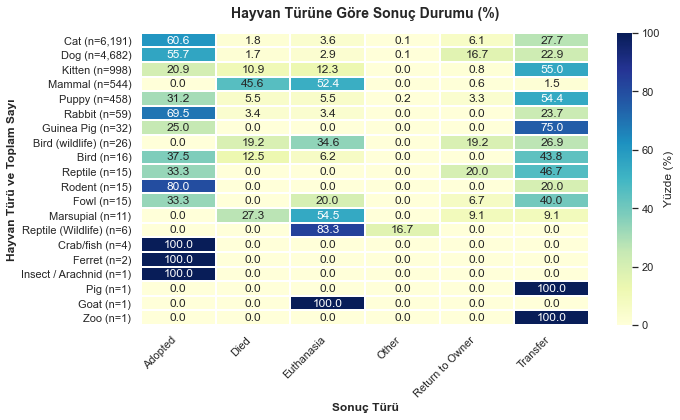

In [4]:
# 1. Her hayvan türü için toplam sayıları hesaplayalım
type_counts = df['Type'].value_counts()

# 2. Yüzdeler için çapraz tabloyu (crosstab) oluşturalım
outcome_crosstab = pd.crosstab(
    index=df['Type'], 
    columns=df['Outcome_Macro'], 
    normalize='index' 
) * 100

# outcome_crosstab'i type_counts'un büyükten küçüğe sıralanmış indeksine göre yeniden sıralayalım
outcome_crosstab = outcome_crosstab.loc[type_counts.index]

# 3. Toplam sayıları içerecek şekilde indeks etiketlerini dinamik olarak güncelleyelim "Tür (n=Toplam)"
# ":," sayıyı virgül ayırıcılarla formatlar (örneğin 1,530)
new_index_labels = [f"{animal} (n={type_counts[animal]:,})" for animal in outcome_crosstab.index]
outcome_crosstab.index = new_index_labels

# 4. GÖRSELLEŞTİRME
plt.figure(figsize=(10, 6))
sns.set_theme(style="white")

sns.heatmap(
    outcome_crosstab, 
    annot=True, 
    fmt=".1f", 
    cmap="YlGnBu", 
    linewidths=1, 
    cbar_kws={'label': 'Yüzde (%)'}
)

# Başlıkları ve Etiketleri Ayarlayalım
plt.title("Hayvan Türüne Göre Sonuç Durumu (%)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sonuç Türü", fontsize=12, fontweight='bold')
plt.ylabel("Hayvan Türü ve Toplam Sayı", fontsize=12, fontweight='bold')

# Daha iyi okunabilirlik için x ekseni etiketlerini döndürelim
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

### Görsel Yorumlama: Hayvan Türüne Göre Sonuçlar (Örneklem Boyutları ile)
Bu ısı haritası, makro sonuçların farklı hayvan türleri arasındaki dağılımını görselleştirmektedir. Y ekseni etiketlerine toplam örneklem boyutunu (`n=...`) dinamik olarak ekleyerek, yüzdelere çok önemli bir bağlam sağlıyoruz.

Örneğin, sadece 15 hayvanın bulunduğu bir kategorideki %80'lik transfer oranı, 6.000 hayvanın bulunduğu bir kategorideki %60'lık sahiplendirme oranından çok daha farklı bir operasyonel ağırlığa sahiptir. Bu geliştirme, paydaşların barınak ekosisteminin şeffaf ve kapsamlı bir görünümünü sağlayarak her bir sonucun hem göreceli oranlarını hem de mutlak hacmini anında değerlendirebilmelerini sağlar.

In [5]:
# 2. Makro kategorimize dayanarak başarılı sahiplendirmeleri filtreleyelim
df_adopted = df[df['Outcome_Macro'] == 'Adopted'].copy()

# 3. 'Naming_Status' özelliğini (feature) oluşturalım ('Unknown' ve NaN değerlerini ele alarak)
df_adopted['Naming_Status'] = np.where(
    df_adopted['Name'].isna() | (df_adopted['Name'] == 'Unknown') | (df_adopted['Name'] == ''), 
    'Unnamed', 
    'Named'
)

print(f"Analiz İçin Filtrelenmiş Toplam Sahiplenilmiş Hayvan Sayısı: {len(df_adopted)}")

Analiz İçin Filtrelenmiş Toplam Sahiplenilmiş Hayvan Sayısı: 6799


## 2. Keşifçi Veri Analizi (EDA)
Barınak verilerinde, bekleme süreleri aşırı sağa çarpıklık gösterebilir (bazı hayvanlar ne yazık ki yıllarca beklemektedir). Bu nedenle, "tipik" bir hayvanın sahiplenilme yolculuğunu anlamak için **Medyan (Ortanca)** en güvenilir metriktir.

In [6]:
# İki grubu karşılaştıran temel istatistikleri oluşturalım
core_stats = df_adopted.groupby('Naming_Status')['Days in Shelter'].agg(['count', 'median', 'mean'])
print("Temel İstatistikler: Barınakta Geçirilen Gün Sayısı (Sadece Sahiplenilen Hayvanlar)\n")
print(core_stats)

Temel İstatistikler: Barınakta Geçirilen Gün Sayısı (Sadece Sahiplenilen Hayvanlar)

               count  median        mean
Naming_Status                           
Named           5480   253.0  243.896342
Unnamed         1319   299.0  258.739196


Hayvan Türüne Göre İsimlendirme Oranları (%):

Naming_Status       Named  Unnamed
Type                              
Fowl                40.00    60.00
Kitten              54.07    45.93
Reptile             60.00    40.00
Bird                66.67    33.33
Cat                 74.47    25.53
Puppy               83.92    16.08
Rabbit              87.80    12.20
Dog                 91.23     8.77
Rodent              91.67     8.33
Crab/fish          100.00     0.00
Ferret             100.00     0.00
Guinea Pig         100.00     0.00
Insect / Arachnid  100.00     0.00


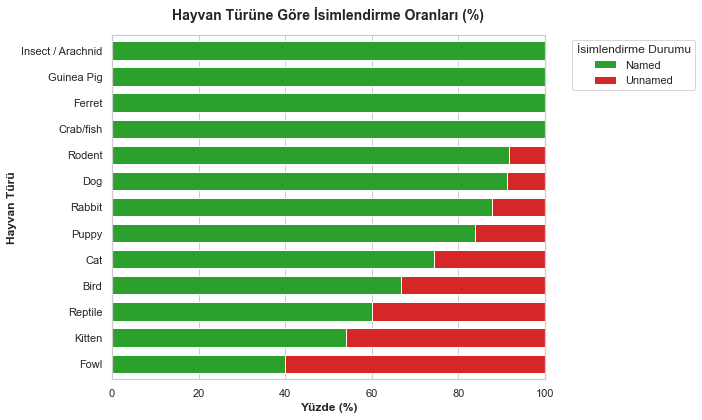

In [7]:
# Hayvan türüne göre isimlendirme oranlarını hesaplayalım
naming_rates_table = pd.crosstab(
    index=df_adopted['Type'],            # Satırlarda hayvan türleri
    columns=df_adopted['Naming_Status'], # Sütunlarda isimlendirme durumu
    normalize='index'                    # Her bir hayvan türü içindeki yüzdeyi hesaplayalım
) * 100                                  # Yüzde formatına dönüştürmek için 100 ile çarpalım

# 'Unnamed' (İsimsiz) sütununa göre azalan sırada sıralayalım
naming_rates_table = naming_rates_table.sort_values(by='Unnamed', ascending=False)

print("Hayvan Türüne Göre İsimlendirme Oranları (%):\n")
print(naming_rates_table.round(2))

# --- GÖRSELLEŞTİRME ---
# Profesyonel portföy teması
sns.set_theme(style="whitegrid")

# Çapraz tabloyu (crosstab) kullanarak %100 Yığılmış Yatay Çubuk Grafik oluşturalım
# Pandas'ın yerleşik plot fonksiyonu yığılmış çubuk grafikler için oldukça etkilidir
naming_rates_table.plot(
    kind='barh', 
    stacked=True, 
    figsize=(10, 6), 
    color=['#2ca02c', '#d62728'], # Yeşil - Kırmızı kontrastı
    width=0.7,
    edgecolor='white'             # Temiz bir görünüm için çubuklar arasına ince beyaz bir çizgi ekler
)

# Başlıkları ve Etiketleri Ayarlayalım
plt.title("Hayvan Türüne Göre İsimlendirme Oranları (%)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Yüzde (%)", fontsize=12, fontweight='bold')
plt.ylabel("Hayvan Türü", fontsize=12, fontweight='bold')

# X ekseni sınırını kesin olarak 0 ile 100 arasına sabitleyelim
plt.xlim(0, 100)

# Çubukları engellememesi için lejantı grafiğin dışına, sağ üst köşeye taşıyalım
plt.legend(title='İsimlendirme Durumu', bbox_to_anchor=(1.05, 1), loc='upper left')

# Metinlerin veya lejantın kesilmesini önlemek için düzeni optimize edelim
plt.tight_layout()
plt.show()

### Görsel Yorumlama: Hayvan Türüne Göre İsimlendirme Oranları
Bu %100 yığılmış yatay çubuk grafik, isimlendirme dağılımını sahiplenilen popülasyon içindeki farklı hayvan türleri arasında göstermektedir. Verileri normalize ederek (`normalize='index'`), her bir tür için toplam popülasyon büyüklüğüne bakılmaksızın isimlendirilmiş ve isimlendirilmemiş hayvanların oranını doğrudan karşılaştırabiliriz.

Bu görselleştirme, "isimsiz" sorununun barınak genelinde sistemik mi yoksa belirli hayvan türlerine mi özgü olduğunu belirlemeye yardımcı olarak, yönetimin isimlendirme protokollerini daha etkili bir şekilde hedeflemesini sağlar.

### Temel Dağılımın Görselleştirilmesi
Sahiplenme hızlarındaki farkı açıkça ifade etmek için bir Kutu Grafiği (Boxplot) kullanıyoruz. 
*Analitik Not:* Aykırı değerleri (outliers) geçici olarak gizlemek için `showfliers=False` parametresini uyguluyoruz. Bu, görsel gürültüyü ortadan kaldırır ve paydaşların yalnızca ana popülasyonun medyan bekleme sürelerindeki değişime odaklanmasına olanak tanır.

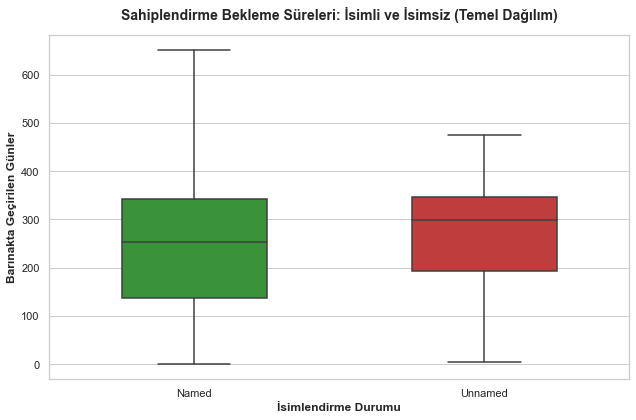

In [8]:
plt.figure(figsize=(9, 6))

sns.boxplot(
    data=df_adopted, 
    x='Naming_Status', 
    y='Days in Shelter', 
    palette=['#2ca02c', '#d62728'],
    showfliers=False, 
    width=0.5
)

plt.title("Sahiplendirme Bekleme Süreleri: İsimli ve İsimsiz (Temel Dağılım)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("İsimlendirme Durumu", fontsize=12, fontweight='bold')
plt.ylabel("Barınakta Geçirilen Günler", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

### Görsel Yorumlama: Merkezi Eğilim Kayması
Boxplot, iki grup arasındaki merkezi eğilimde belirgin bir kayma olduğunu açıkça göstermektedir. Aykırı değerler (outliers) gizlendiğinde şu operasyonel gerçekler öne çıkmaktadır::
* **Medyan Avantajı:** İsimlendirilmiş hayvanlar için medyan kalış süresi (yeşil kutudaki orta çizgi ile temsil edilir), isimlendirilmemiş hayvanlara (kırmızı kutu) göre belirgin şekilde daha düşüktür. Bu da isimlendirmenin sahiplendirme sürecini hızlandırdığını gösterir.
* **Dağılım ve Varyans:** İsimlendirilmemiş hayvanların kutu boyu (Çeyrekler Arası Aralık - IQR) daha dar olsa da, bu grup daha yüksek bekleme sürelerinde yoğunlaşmaktadır. İsimlendirilmiş hayvanlar ise daha geniş bir zaman yayılımına sahip olmakla birlikte, popülasyonun büyük bir kısmı y ekseninin çok daha alt seviyelerinde, yani barınakta çok daha az gün geçirerek sahiplenilmektedir.

Bu görsel kanıt, bir ismin potansiyel sahipleniciler için psikolojik bir çapa görevi gördüğü ve dolayısıyla sahiplendirme sürecini hızlandırdığı hipotezini güçlü bir şekilde desteklemektedir.

## 3. İstatistiksel Analiz ve Hipotez Testi

Görsel bulgularımızı matematiksel olarak doğrulamak için bağımsız örneklemler t-testi yapıyoruz. Gruplar arasındaki örneklem büyüklüklerimiz ve varyanslarımız eşit olmadığı için **Welch'in t-testini** (`equal_var=False`) kullanıyoruz.

**Hipotezler:**
* **$H_0$ (Sıfır Hipotezi):** İsimlendirilmiş ve isimlendirilmemiş hayvanların sahiplenilene kadar barınakta geçirdikleri ortalama gün sayısı arasında anlamlı bir fark yoktur.
* **$H_A$ (Alternatif Hipotez):** İsimlendirilmiş hayvanlar barınakta anlamlı ölçüde daha az gün geçirirler.

In [9]:
# İstatistiksel test için sayısal serileri filtreleyelim
named_group = df_adopted[df_adopted['Naming_Status'] == 'Named']['Days in Shelter'].dropna()
unnamed_group = df_adopted[df_adopted['Naming_Status'] == 'Unnamed']['Days in Shelter'].dropna()

# Welch t-testini uygulayalım
t_stat, p_value = stats.ttest_ind(named_group, unnamed_group, equal_var=False)

print(f"T-istatistiği: {t_stat:.4f}")
print(f"P-değeri: {p_value:.6f}")

if p_value < 0.05:
    print("\nSonuç: Sıfır Hipotezini (H0) reddet. Sahiplendirme süreleri arasındaki fark istatistiksel olarak anlamlıdır.")
else:
    print("\nSonuç: Sıfır Hipotezi (H0) reddedilemedi.")

T-istatistiği: -4.0585
P-değeri: 0.000051

Sonuç: Sıfır Hipotezini (H0) reddet. Sahiplendirme süreleri arasındaki fark istatistiksel olarak anlamlıdır.


## 4. Derinlemesine İnceleme: Aykırı Değer Paradoksu (Zaman Yanlılığı)
Medyan isimlendirilmiş hayvanların lehine güçlü bir şekilde eğilim gösterse de, matematiksel *ortalama* iki grup arasında birbirine daha yakın görünmektedir. Yüzdelik dilim analizi, "İsimli" kategorisinin aşırı uç değerler (600+ gün kalan hayvanlar) içerdiğini ortaya koymaktadır.

In [10]:
percentiles = [0.75, 0.90, 0.95, 0.99]
percentile_table = df_adopted.groupby('Naming_Status')['Days in Shelter'].quantile(percentiles).unstack()

print("Barınakta Geçirilen Süre Yüzdelik Dilimleri:\n")
print(percentile_table)

Barınakta Geçirilen Süre Yüzdelik Dilimleri:

                0.75   0.90   0.95    0.99
Naming_Status                             
Named          343.0  390.0  428.0  603.05
Unnamed        347.0  371.0  386.0  407.00


Bu, klasik bir **Zaman Yanlılığı (Time Bias)** örneğidir: Sahiplenilmesi çok zor olan hayvanlar barınakta daha uzun süre kalırlar. Daha uzun kaldıkça, barınak personelinin bağ kurması ve eninde sonunda onlara bir isim vermesi kaçınılmaz hale gelir. Bu nedenle, "İsimli" kategorisi doğal olarak tüm aşırı kronik vakaları kendi içine çeker. Ancak, popülasyonun ezici çoğunluğu için isimlendirme, sahiplenmeyi güçlü bir şekilde hızlandırır.

## 5. Sonuç ve Bağlamsal Değerlendirme
Veri analitiği süreci temel hipotezi başarıyla kanıtlamıştır: **Bir isim verilen hayvanlar barınaktan önemli ölçüde daha hızlı sahiplenilmektedir.**

Ancak bu analizin verileri Austin, Teksas gibi yüksek bütçeli, gelişmiş altyapıya sahip bir sistemden gelmektedir. Türkiye’deki mevcut barınak şartları (aşırı yoğunluk, kaynak yetersizliği, yüksek enfeksiyon ve ölüm riskleri) göz önüne alındığında, bu bulguyu sadece bir "barınak operasyonel verimlilik metriği" olarak okumak yetersiz kalacaktır. Ülkemiz gerçekliğinde barınakta geçirilen gün sayısının azaltılması, bir bütçe tasarrufundan ziyade doğrudan bir hayatta kalma mücadelesidir. Hayvanın barınak ortamında kaldığı her gün, sağlığı için hayati bir risk teşkil eder.

**Tavsiye:**
Bu bulgu, sokak hayvanlarının refahını iyileştirmek için çalışan sivil toplum kuruluşları (STK’lar), yerel gönüllü ağları ve dijital sahiplendire platformları için uygulanabilir bir kılavuz işlevi görmelidir. Sosyal medyadaki “Acil Sahiplendirme” paylaşımlarında hayvanları “İsimsiz” veya sadece “Yavru Kedi/Köpek” olarak listelemek, onları görünmez kılar. Hayvanlara karakterlerini yansıtan isimler vermek, potansiyel yeni aileleri ile hızlı bir bağ kurulmasına yardımcı olur. Bu basit, maliyeti sıfır olan dokunuş, hayvanların ölümcül barınak döngüsüne hiç girmeden ya da bu koşullardan mümkün olduğunca çabuk kaçarak sonsuza kadar kalacakları yuvalarını bulmalarına yardımcı olacaktır.